In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# ============================================================
# DIÁMETROS CARACTERÍSTICOS DE GRANO
# ============================================================

# Granulometría de las séries 1 y 2
# Diámetros medios de cada clase granulométrica [mm]
diametros_mm_12 = np.array([
    0.325, 0.225, 0.180, 0.130, 0.090, 0.0715
])

# Fracciones másicas asociadas a cada clase [-]
fracciones_12 = np.array([
    0.275, 0.150, 0.191, 0.202, 0.091, 0.091
])

# Verificación de que las fracciones sumen 1
print(f"Suma de fracciones séries 1-2 = {fracciones_12.sum():.6f}")

# Diámetro de Sauter para las séries polidispersas 1 y 2
dg_12_mm = 1 / np.sum(fracciones_12 / diametros_mm_12)

# Diámetro nominal para las séries 3, 4 y 5
dg_345_mm = 0.325

# Conversión a metros
dg_12 = dg_12_mm / 1000
dg_345 = dg_345_mm / 1000

print(f"d_g séries 1-2 = {dg_12_mm:.6f} mm = {dg_12:.6e} m")
print(f"d_g séries 3-5 = {dg_345_mm:.6f} mm = {dg_345:.6e} m")

Suma de fracciones séries 1-2 = 1.000000
d_g séries 1-2 = 0.155967 mm = 1.559669e-04 m
d_g séries 3-5 = 0.325000 mm = 3.250000e-04 m


In [ ]:
# ============================================================
# DATOS DE LAS SÉRIES 1 Y 2
# Grupo polidisperso
# d_g calculado con el diámetro de Sauter
# ============================================================

datos_12 = pd.DataFrame({
    "muestra": [
        "1-A", "1-B", "1-C", "1-D", "1-E", "1-F",
        "2-A", "2-B", "2-C", "2-D"
    ],

    "serie": [
        1, 1, 1, 1, 1, 1,
        2, 2, 2, 2
    ],

    # Porosité effective mesurée par saturation [-]
    "phi": [
        0.245570, 0.115521, 0.204140,
        0.250084, 0.162163, 0.106729,

        0.242391, 0.246406, 0.103679, 0.066769
    ],

    # Perméabilité intrinsèque corrigée [m²]
    # Pour la série 1, on utilise la moyenne des deux mesures
    "k_m2": [
        np.mean([1.274519e-12, 7.441038e-13]),   # 1-A
        np.mean([2.730022e-13, 1.200269e-13]),   # 1-B
        np.mean([4.128039e-12, 1.317924e-12]),   # 1-C
        np.mean([6.348282e-12, 7.712834e-12]),   # 1-D
        np.mean([8.622321e-12, 6.154245e-12]),   # 1-E
        np.mean([6.468356e-13, 5.578148e-13]),   # 1-F

        1.231865e-11,   # 2-A
        4.767726e-12,   # 2-B
        8.670732e-13,   # 2-C
        1.497172e-13    # 2-D
    ]
})

# Diámetro característico asignado explícitamente al grupo 1-2
datos_12["dg_m"] = dg_12

# Verificación
print("Séries contenues dans datos_12 :", datos_12["serie"].unique())
display(datos_12)

Séries contenues dans datos_12 : [1 2]


,muestra,serie,phi,k_m2,dg_m
0,1-A,1,0.245570,1.009311e-12,0.000156
1,1-B,1,0.115521,1.965145e-13,0.000156
2,1-C,1,0.204140,2.722982e-12,0.000156
3,1-D,1,0.250084,7.030558e-12,0.000156
4,1-E,1,0.162163,7.388283e-12,0.000156
5,1-F,1,0.106729,6.023252e-13,0.000156
6,2-A,2,0.242391,1.231865e-11,0.000156
7,2-B,2,0.246406,4.767726e-12,0.000156
8,2-C,2,0.103679,8.670732e-13,0.000156
9,2-D,2,0.066769,1.497172e-13,0.000156


In [ ]:
# ============================================================
# DATOS DE LAS SÉRIES 3, 4 Y 5
# Grupo considerado monodisperso o faiblement dispersé
# d_g tomado como diámetro nominal
# ============================================================

datos_345 = pd.DataFrame({
    "muestra": [
        "3-A", "3-B", "3-C", "3-D", "3-E", "3-F",
        "4-A", "4-B", "4-C", "4-D", "4-E", "4-F",
        "5-A", "5-B", "5-C", "5-D",
        "5-E", "5-F", "5-G", "5-H"
    ],

    "serie": [
        3, 3, 3, 3, 3, 3,
        4, 4, 4, 4, 4, 4,
        5, 5, 5, 5, 5, 5, 5, 5
    ],

    # Porosité effective mesurée par saturation [-]
    "phi": [
        0.274999, 0.202305, 0.212858,
        0.166387, 0.192829, 0.141985,

        0.320336, 0.326602, 0.287416,
        0.260955, 0.230453, 0.227902,

        0.255417, 0.274515, 0.213509, 0.229086,
        0.189196, 0.203789, 0.212226, 0.208782
    ],

    # Perméabilité intrinsèque corrigée [m²]
    "k_m2": [
        1.896604e-11,   # 3-A
        1.006328e-11,   # 3-B
        9.485004e-12,   # 3-C
        8.041334e-12,   # 3-D
        1.024414e-11,   # 3-E
        1.652409e-11,   # 3-F

        1.852425e-11,   # 4-A
        2.746882e-11,   # 4-B
        1.383623e-11,   # 4-C
        1.943298e-11,   # 4-D
        1.388943e-11,   # 4-E
        1.245219e-11,   # 4-F

        1.446747e-11,   # 5-A
        1.882958e-11,   # 5-B
        1.113738e-11,   # 5-C
        1.367283e-11,   # 5-D
        9.072794e-12,   # 5-E
        1.177038e-11,   # 5-F
        1.170844e-11,   # 5-G
        1.000900e-11    # 5-H
    ]
})

# Diámetro característico asignado explícitamente al grupo 3-5
datos_345["dg_m"] = dg_345

# Verificación
print("Séries contenues dans datos_345 :", datos_345["serie"].unique())
display(datos_345)

Séries contenues dans datos_345 : [3 4 5]


,muestra,serie,phi,k_m2,dg_m
0,3-A,3,0.274999,1.896604e-11,0.000325
1,3-B,3,0.202305,1.006328e-11,0.000325
2,3-C,3,0.212858,9.485004e-12,0.000325
3,3-D,3,0.166387,8.041334e-12,0.000325
4,3-E,3,0.192829,1.024414e-11,0.000325
5,3-F,3,0.141985,1.652409e-11,0.000325
6,4-A,4,0.320336,1.852425e-11,0.000325
7,4-B,4,0.326602,2.746882e-11,0.000325
8,4-C,4,0.287416,1.383623e-11,0.000325
9,4-D,4,0.260955,1.943298e-11,0.000325


In [ ]:
# ============================================================
# CÁLCULO SEPARADO DEL TÉRMINO DE KOZENY-CARMAN
# X = d_g² * phi³ / (1 - phi)²
# ============================================================

# Para séries 1-2
X_KC_12 = (
    dg_12**2
    * datos_12["phi"]**3
    / (1 - datos_12["phi"])**2
)

# Para séries 3-5
X_KC_345 = (
    dg_345**2
    * datos_345["phi"]**3
    / (1 - datos_345["phi"])**2
)

# Guardar cada X con un nombre diferente
datos_12["X_KC_12"] = X_KC_12
datos_345["X_KC_345"] = X_KC_345

display(datos_12[["muestra", "serie", "phi", "k_m2", "dg_m", "X_KC_12"]])
display(datos_345[["muestra", "serie", "phi", "k_m2", "dg_m", "X_KC_345"]])

,muestra,serie,phi,k_m2,dg_m,X_KC_12
0,1-A,1,0.245570,1.009311e-12,0.000156,6.329261e-10
1,1-B,1,0.115521,1.965145e-13,0.000156,4.793721e-11
2,1-C,1,0.204140,2.722982e-12,0.000156,3.267202e-10
3,1-D,1,0.250084,7.030558e-12,0.000156,6.765462e-10
4,1-E,1,0.162163,7.388283e-12,0.000156,1.477751e-10
5,1-F,1,0.106729,6.023252e-13,0.000156,3.706345e-11
6,2-A,2,0.242391,1.231865e-11,0.000156,6.035652e-10
7,2-B,2,0.246406,4.767726e-12,0.000156,6.408316e-10
8,2-C,2,0.103679,8.670732e-13,0.000156,3.374506e-11
9,2-D,2,0.066769,1.497172e-13,0.000156,8.314024e-12


,muestra,serie,phi,k_m2,dg_m,X_KC_345
0,3-A,3,0.274999,1.896604e-11,0.000325,4.179101e-09
1,3-B,3,0.202305,1.006328e-11,0.000325,1.374399e-09
2,3-C,3,0.212858,9.485004e-12,0.000325,1.644109e-09
3,3-D,3,0.166387,8.041334e-12,0.000325,7.001578e-10
4,3-E,3,0.192829,1.024414e-11,0.000325,1.162392e-09
5,3-F,3,0.141985,1.652409e-11,0.000325,4.106808e-10
6,4-A,4,0.320336,1.852425e-11,0.000325,7.516150e-09
7,4-B,4,0.326602,2.746882e-11,0.000325,8.114833e-09
8,4-C,4,0.287416,1.383623e-11,0.000325,4.938868e-09
9,4-D,4,0.260955,1.943298e-11,0.000325,3.436543e-09


In [ ]:
# ============================================================
# COMPARAISON DE DEUX MÉTHODES POUR CALCULER C
# ============================================================

# Coefficients individuels :
# C_i = X_KC / k_exp

datos_12["C_i_12"] = datos_12["X_KC_12"] / datos_12["k_m2"]
datos_345["C_i_345"] = datos_345["X_KC_345"] / datos_345["k_m2"]


# ============================================================
# MÉTHODE 1 : MOYENNE LOGARITHMIQUE
# C_log = exp(mean(log(X_KC / k)))
# ============================================================

C_log_12 = np.exp(
    np.mean(
        np.log(datos_12["C_i_12"])
    )
)

C_log_345 = np.exp(
    np.mean(
        np.log(datos_345["C_i_345"])
    )
)


# ============================================================
# MÉTHODE 2 : MOYENNE ARITHMÉTIQUE
# C_moy = mean(X_KC / k)
# ============================================================

C_moy_12 = np.mean(datos_12["C_i_12"])
C_moy_345 = np.mean(datos_345["C_i_345"])


print("Coefficients C obtenus")
print("-----------------------------")
print(f"C_log séries 1-2 = {C_log_12:.6f}")
print(f"C_moy séries 1-2 = {C_moy_12:.6f}")
print()
print(f"C_log séries 3-5 = {C_log_345:.6f}")
print(f"C_moy séries 3-5 = {C_moy_345:.6f}")

Coefficients C obtenus
-----------------------------
C_log séries 1-2 = 88.930452
C_moy séries 1-2 = 144.663127

C_log séries 3-5 = 157.537642
C_moy séries 3-5 = 179.685761


In [ ]:
# ============================================================
# PERMÉABILITÉS MODÈLE POUR LES DEUX MÉTHODES
# ============================================================

# Séries 1-2
datos_12["k_KC_log_12_m2"] = datos_12["X_KC_12"] / C_log_12
datos_12["k_KC_moy_12_m2"] = datos_12["X_KC_12"] / C_moy_12

# Séries 3-5
datos_345["k_KC_log_345_m2"] = datos_345["X_KC_345"] / C_log_345
datos_345["k_KC_moy_345_m2"] = datos_345["X_KC_345"] / C_moy_345

In [ ]:
# ============================================================
# FONCTION POUR CALCULER R² LINÉAIRE ET R² LOGARITHMIQUE
# ============================================================

def calculer_R2(k_exp, k_modele):
    """
    Calcule deux coefficients de détermination :
    - R2_lin : sur les valeurs directes de k
    - R2_log : sur log10(k)
    """

    k_exp = np.asarray(k_exp)
    k_modele = np.asarray(k_modele)

    # R² en échelle linéaire
    SS_res_lin = np.sum((k_exp - k_modele)**2)
    SS_tot_lin = np.sum((k_exp - np.mean(k_exp))**2)
    R2_lin = 1 - SS_res_lin / SS_tot_lin

    # R² en échelle logarithmique
    log_k_exp = np.log10(k_exp)
    log_k_modele = np.log10(k_modele)

    SS_res_log = np.sum((log_k_exp - log_k_modele)**2)
    SS_tot_log = np.sum((log_k_exp - np.mean(log_k_exp))**2)
    R2_log = 1 - SS_res_log / SS_tot_log

    return R2_lin, R2_log

In [ ]:
# ============================================================
# CALCUL DES R² POUR CHAQUE GROUPE ET CHAQUE MÉTHODE
# ============================================================

# Séries 1-2, méthode logarithmique
R2_lin_log_12, R2_log_log_12 = calculer_R2(
    datos_12["k_m2"],
    datos_12["k_KC_log_12_m2"]
)

# Séries 1-2, méthode moyenne arithmétique
R2_lin_moy_12, R2_log_moy_12 = calculer_R2(
    datos_12["k_m2"],
    datos_12["k_KC_moy_12_m2"]
)

# Séries 3-5, méthode logarithmique
R2_lin_log_345, R2_log_log_345 = calculer_R2(
    datos_345["k_m2"],
    datos_345["k_KC_log_345_m2"]
)

# Séries 3-5, méthode moyenne arithmétique
R2_lin_moy_345, R2_log_moy_345 = calculer_R2(
    datos_345["k_m2"],
    datos_345["k_KC_moy_345_m2"]
)


comparaison_C = pd.DataFrame({
    "groupe": [
        "Séries 1-2",
        "Séries 1-2",
        "Séries 3-5",
        "Séries 3-5"
    ],

    "méthode": [
        "moyenne logarithmique",
        "moyenne arithmétique de X/k",
        "moyenne logarithmique",
        "moyenne arithmétique de X/k"
    ],

    "C": [
        C_log_12,
        C_moy_12,
        C_log_345,
        C_moy_345
    ],

    "R2_lin": [
        R2_lin_log_12,
        R2_lin_moy_12,
        R2_lin_log_345,
        R2_lin_moy_345
    ],

    "R2_log": [
        R2_log_log_12,
        R2_log_moy_12,
        R2_log_log_345,
        R2_log_moy_345
    ]
})

display(comparaison_C)

,groupe,méthode,C,R2_lin,R2_log
0,Séries 1-2,moyenne logarithmique,88.930452,0.282059,0.598485
1,Séries 1-2,moyenne arithmétique de X/k,144.663127,0.173483,0.489502
2,Séries 3-5,moyenne logarithmique,157.537642,-3.903973,-2.371749
3,Séries 3-5,moyenne arithmétique de X/k,179.685761,-2.175203,-2.554638


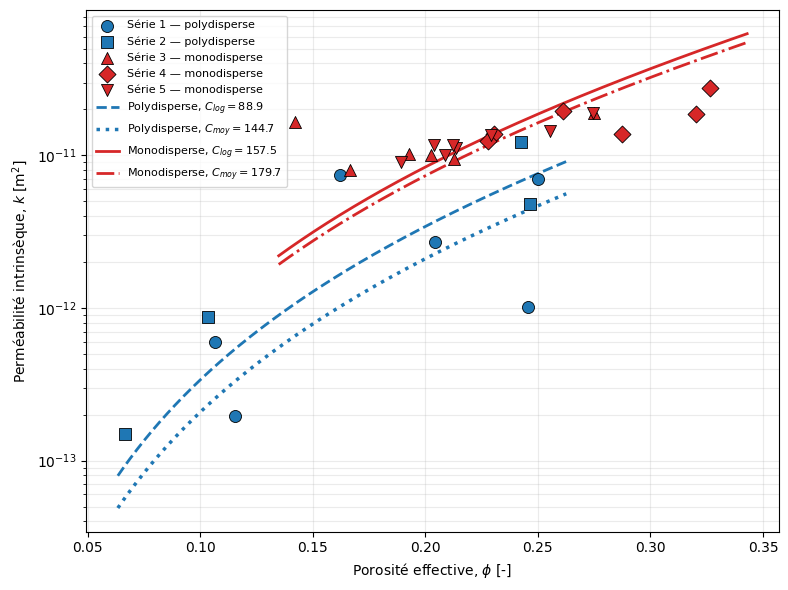

In [ ]:
# ============================================================
# GRAPHIQUE COMPARANT LES DEUX MÉTHODES DE CALCUL DE C
# Points colorés selon le type granulométrique
# ============================================================

plt.figure(figsize=(8, 6))


# ============================================================
# COULEURS ET MARQUEURS
# ============================================================

# Couleurs par type de matériau
couleurs_type = {
    "polydisperse": "tab:blue",      # Séries 1-2
    "monodisperse": "tab:red"        # Séries 3-5
}

# Marqueurs par série
marcadores = {
    1: "o",
    2: "s",
    3: "^",
    4: "D",
    5: "v"
}

# Type granulométrique par série
type_granulo = {
    1: "polydisperse",
    2: "polydisperse",
    3: "monodisperse",
    4: "monodisperse",
    5: "monodisperse"
}


# ============================================================
# POINTS EXPÉRIMENTAUX
# ============================================================

datos_KC = pd.concat([datos_12, datos_345], ignore_index=True)

for serie in sorted(datos_KC["serie"].unique()):
    subset = datos_KC[datos_KC["serie"] == serie]
    type_i = type_granulo[serie]

    plt.scatter(
        subset["phi"],
        subset["k_m2"],
        color=couleurs_type[type_i],
        marker=marcadores[serie],
        s=75,
        label=f"Série {serie} — {type_i}",
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )


# ============================================================
# COURBES POUR LES SÉRIES 1-2 : MATÉRIAUX POLYDISPERSES
# ============================================================

phi_modelo_12 = np.linspace(
    datos_12["phi"].min() * 0.95,
    datos_12["phi"].max() * 1.05,
    300
)

X_modelo_12 = (
    dg_12**2
    * phi_modelo_12**3
    / (1 - phi_modelo_12)**2
)

k_modelo_log_12 = X_modelo_12 / C_log_12
k_modelo_moy_12 = X_modelo_12 / C_moy_12

plt.plot(
    phi_modelo_12,
    k_modelo_log_12,
    color=couleurs_type["polydisperse"],
    linestyle="--",
    linewidth=2,
    label=rf"Polydisperse, $C_{{log}}={C_log_12:.1f}$"
)

plt.plot(
    phi_modelo_12,
    k_modelo_moy_12,
    color=couleurs_type["polydisperse"],
    linestyle=":",
    linewidth=2.5,
    label=rf"Polydisperse, $C_{{moy}}={C_moy_12:.1f}$"
)


# ============================================================
# COURBES POUR LES SÉRIES 3-5 : MATÉRIAUX MONODISPERSES
# ============================================================

phi_modelo_345 = np.linspace(
    datos_345["phi"].min() * 0.95,
    datos_345["phi"].max() * 1.05,
    300
)

X_modelo_345 = (
    dg_345**2
    * phi_modelo_345**3
    / (1 - phi_modelo_345)**2
)

k_modelo_log_345 = X_modelo_345 / C_log_345
k_modelo_moy_345 = X_modelo_345 / C_moy_345

plt.plot(
    phi_modelo_345,
    k_modelo_log_345,
    color=couleurs_type["monodisperse"],
    linestyle="-",
    linewidth=2,
    label=rf"Monodisperse, $C_{{log}}={C_log_345:.1f}$"
)

plt.plot(
    phi_modelo_345,
    k_modelo_moy_345,
    color=couleurs_type["monodisperse"],
    linestyle="-.",
    linewidth=2,
    label=rf"Monodisperse, $C_{{moy}}={C_moy_345:.1f}$"
)


# ============================================================
# MISE EN FORME
# ============================================================

plt.yscale("log")

plt.xlabel(r"Porosité effective, $\phi$ [-]")
plt.ylabel(r"Perméabilité intrinsèque, $k$ [m$^2$]")

plt.grid(True, which="both", alpha=0.25)
plt.legend(fontsize=8)

plt.tight_layout()

plt.savefig("comparaison_KC_C_log_C_moy_groupes.png", dpi=300)
plt.show()